# import


In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm
from IPython.display import display

warnings.filterwarnings("ignore")

# Settings

In [ ]:
DATA_DIR = Path("../Binance_data/processed_parquet") # 1분봉 parquet 파일 폴더
OUTPUT_DIR = Path("crypto_universe_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_CORES = 20    # 28
TOP_N = 200     # formation year별 top N

# FORMATION_YEARS = [2018, 2019, 2020, 2021, 2022, 2023]    # 확인할 formation years
GLOBAL_END_DATE = "2025-12-31"                      # 데이터 전체 분석 종료일

EXPECTED_MINUTES_PER_DAY = 1440     # 1분봉 데이터 기준                     
# MIN_MINUTES_PER_DAY = 720           # 이상만 alive day로 간주
# MIN_OBSERVED_DAYS_IN_FORMATION = 250    # formation year에서 최소 며칠 이상 거래된 코인만 top 200 후보로 인정 (Universe 만들기 위함)
# MIN_OBSERVED_DAYS_FOR_SURVIVAL = 250    # Universe에 속한 코인이 이후 연도들에서 각각 며칠 이상 살아남았는지 확인

# Functions: Data Load

In [3]:
# 파일명에서 ticker 추출
# "_" 전까지를 ticker로 사용
def normalize_ticker_from_filename(file_path: str) -> str:
    fname = os.path.basename(file_path)
    fname = fname.replace(".parquet", "")
    ticker = fname.split("_")[0]
    return ticker

# 단일 코인의 1분봉 parquet 파일을 읽기, 날짜별 minute coverage와 quote volume 요약.
# 반환: ticker, date, n_minutes, quote_volume, first_timestamp, last_timestamp
def summarize_one_minute_parquet(file_path: str) -> pd.DataFrame:
    ticker = normalize_ticker_from_filename(file_path)

    df = pd.read_parquet(file_path)

    tmp = pd.DataFrame({
        "datetime": pd.to_datetime(df.index),
        "quote_volume": df["quote_asset_volume"].astype(float).values
    })

    tmp["date"] = tmp["datetime"].dt.floor("D")

    out = (
        tmp
        .groupby("date")
        .agg(
            n_minutes=("datetime", "nunique"),
            quote_volume=("quote_volume", "sum"),
            first_timestamp=("datetime", "min"),
            last_timestamp=("datetime", "max")
        )
        .reset_index()
    )

    out["ticker"] = ticker

    out = out[
        [
            "ticker", "date", "n_minutes", "quote_volume", "first_timestamp", "last_timestamp"
        ]
    ]

    return out

In [4]:
# 모든 parquet 파일을 읽어서 ticker-date 단위 summary 생성
def build_daily_minute_summary(data_dir: str, n_jobs: int = N_CORES) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(data_dir, "*.parquet")))

    print(f"[Files] {len(files):,} parquet files found.")

    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(summarize_one_minute_parquet)(f)
        for f in files
    )

    summary = pd.concat(results, ignore_index=True)

    summary["date"] = pd.to_datetime(summary["date"])
    summary["year"] = summary["date"].dt.year

    summary["raw_missing_minutes"] = EXPECTED_MINUTES_PER_DAY - summary["n_minutes"]
    summary["missing_minutes"] = summary["raw_missing_minutes"].clip(lower=0)
    summary["extra_minutes"] = (summary["n_minutes"] - EXPECTED_MINUTES_PER_DAY).clip(lower=0)
    summary["missing_ratio"] = summary["missing_minutes"] / EXPECTED_MINUTES_PER_DAY
    # summary["is_alive_day"] = summary["n_minutes"] >= MIN_MINUTES_PER_DAY

    print("\n[Daily Minute Summary]")
    print(f"Rows       : {len(summary):,}")
    print(f"Tickers    : {summary['ticker'].nunique():,}")
    print(f"Date range : {summary['date'].min().date()} ~ {summary['date'].max().date()}")

    return summary

# Execution: Data Load

In [5]:
daily_summary = build_daily_minute_summary(
    data_dir=DATA_DIR,
    n_jobs=N_CORES
)

# daily_summary.to_parquet(
#     os.path.join(OUTPUT_DIR, "daily_minute_summary_all_quotes.parquet"),
#     index=False
# )

display(daily_summary.head())
display(daily_summary.describe())

[Files] 3,444 parquet files found.


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  32 tasks      | elapsed:    2.3s
[Parallel(n_jobs=20)]: Done 122 tasks      | elapsed:   10.2s
[Parallel(n_jobs=20)]: Done 248 tasks      | elapsed:   19.9s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:   32.7s
[Parallel(n_jobs=20)]: Done 608 tasks      | elapsed:   46.1s
[Parallel(n_jobs=20)]: Done 842 tasks      | elapsed:  1.1min
[Parallel(n_jobs=20)]: Done 1112 tasks      | elapsed:  1.4min
[Parallel(n_jobs=20)]: Done 1418 tasks      | elapsed:  1.8min
[Parallel(n_jobs=20)]: Done 1760 tasks      | elapsed:  2.2min
[Parallel(n_jobs=20)]: Done 2138 tasks      | elapsed:  2.7min
[Parallel(n_jobs=20)]: Done 2552 tasks      | elapsed:  3.1min
[Parallel(n_jobs=20)]: Done 3002 tasks      | elapsed:  3.6min
[Parallel(n_jobs=20)]: Done 3444 out of 3444 | elapsed:  4.3min finished



[Daily Minute Summary]
Rows       : 2,985,767
Tickers    : 3,444
Date range : 2017-07-14 ~ 2025-12-31


,ticker,date,n_minutes,quote_volume,first_timestamp,last_timestamp,year,raw_missing_minutes,missing_minutes,extra_minutes,missing_ratio
0,0GBNB,2025-09-22,840,1113.835530,2025-09-22 10:00:00,2025-09-22 23:59:00,2025,600,600,0,0.416667
1,0GBNB,2025-09-23,1440,403.463452,2025-09-23 00:00:00,2025-09-23 23:59:00,2025,0,0,0,0.000000
2,0GBNB,2025-09-24,1440,348.958499,2025-09-24 00:00:00,2025-09-24 23:59:00,2025,0,0,0,0.000000
3,0GBNB,2025-09-25,1440,48.511927,2025-09-25 00:00:00,2025-09-25 23:59:00,2025,0,0,0,0.000000
4,0GBNB,2025-09-26,1440,48.437215,2025-09-26 00:00:00,2025-09-26 23:59:00,2025,0,0,0,0.000000


,date,n_minutes,quote_volume,first_timestamp,last_timestamp,year,raw_missing_minutes,missing_minutes,extra_minutes,missing_ratio
count,2985767,2.985767e+06,2.985767e+06,2985767,2985767,2.985767e+06,2.985767e+06,2.985767e+06,2.985767e+06,2.985767e+06
mean,2022-11-08 00:13:56.548000,1.437223e+03,1.191389e+08,2022-11-08 00:14:39.105000,2022-11-09 00:12:05.081000,2.022337e+03,2.776963e+00,2.777020e+00,5.760664e-05,1.928486e-03
min,2017-07-14 00:00:00,1.000000e+00,0.000000e+00,2017-07-14 04:00:00,2017-07-14 23:59:00,2.017000e+03,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2021-06-30 00:00:00,1.440000e+03,1.136971e+02,2021-06-30 00:00:00,2021-06-30 23:59:00,2.021000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2022-12-23 00:00:00,1.440000e+03,1.613419e+05,2022-12-23 00:00:00,2022-12-23 23:59:00,2.022000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2024-07-20 00:00:00,1.440000e+03,2.973726e+06,2024-07-20 00:00:00,2024-07-20 23:59:00,2.024000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2025-12-31 00:00:00,1.441000e+03,2.061546e+13,2025-12-31 00:00:00,2025-12-31 23:59:00,2.025000e+03,1.439000e+03,1.439000e+03,1.000000e+00,9.993056e-01
std,NaN,4.269811e+01,1.220498e+10,NaN,NaN,2.015427e+00,4.269811e+01,4.269811e+01,7.589686e-03,2.965146e-02


In [6]:
# 전체 거래쌍 ticker 수: 3,444개
# 전체 ticker-date 관측치 수: 2,985,767개
# 데이터 기간: 2017-07-14 ~ 2025-12-31

# 대부분의 ticker-date는 하루 1440개 분봉을 거의 온전히 가지고 있음.
# 중앙값 기준으로는 결측률이 0.
# 평균 결측률은 약 0.001928 = 0.1928%.

# Data Preprocessing

## 1. Quote Asset Filtering Rule
- making filtering rules

In [7]:
# Ticker classification rules

# Quote asset candidates: Used to infer quote_asset and base_asset from ticker name
QUOTE_CANDIDATES = [
    # stable / USD-like
    "FDUSD", "USDT", "USDC", "BUSD", "TUSD", "USDP",
    "PAX", "DAI", "USD1", "USDS", "USD", "USTC", "UST",

    # fiat
    "BKRW", "BIDR", "IDRT", "IDR",
    "TRY", "BRL", "EUR", "EURI", "GBP", "AUD",
    "RUB", "NGN", "JPY", "ZAR", "UAH",
    "ARS", "MXN", "PLN", "RON", "COP", "CZK",

    # crypto quote
    "BTC", "ETH", "BNB", "TRX", "XRP", "DOGE", "SOL", "DOT",

    # other
    "VAI", "BVND"
]

QUOTE_CANDIDATES = sorted(
    set(QUOTE_CANDIDATES),
    key=len,
    reverse=True
)

# Base asset exclusion rules: Used to remove non-standard spot-like crypto assets
STABLE_BASES = {
    "USDT", "USDC", "BUSD", "FDUSD", "TUSD", "USDP",
    "PAX", "DAI", "USD1", "USDS", "USD", "UST", "USTC",
    "AEUR", "EURI", "EURC", "PYUSD"
}

FIAT_BASES = {
    "EUR", "GBP", "AUD", "BRL", "TRY", "RUB", "NGN",
    "JPY", "ZAR", "UAH", "ARS", "MXN", "PLN", "RON", "COP", "CZK",
    "BKRW", "BIDR", "IDRT", "IDR"
}

DERIVATIVE_LIKE_BASES = {
    "BETH", "WBETH", "BNSOL", "STETH", "WETH", "WBTC",
    "RETH", "CBETH", "ANKRETH", "RPL"
}

SPECIAL_STRUCTURED_BASES = {
    "BFUSD"
}

FAN_TOKEN_BASES = {
    "ACM", "ASR", "ATM", "BAR", "CITY", "JUV", "LAZIO", "PORTO",
    "PSG", "SANTOS", "ALPINE"
}

LEGACY_FORK_BASES = {
    "BCHABC", "BCHSV", "BCC"
}

# Ticker-pattern exclusion rules: Used to remove leveraged or unit-adjusted tokens
LEVERAGED_SUFFIXES = [
    "UPUSDT",
    "DOWNUSDT",
    "BULLUSDT",
    "BEARUSDT"
]

UNIT_ADJUSTED_PREFIXES = [
    "1000",
    "1M"
]

In [8]:
def infer_quote_asset_from_ticker(ticker: str) -> str:
    for q in QUOTE_CANDIDATES:
        if ticker.endswith(q):
            return q
    return "UNKNOWN"


ticker_quote_map = pd.DataFrame({
    "ticker": sorted(daily_summary["ticker"].unique())
})

ticker_quote_map["quote_asset"] = ticker_quote_map["ticker"].apply(
    infer_quote_asset_from_ticker
)

ticker_quote_map["base_asset"] = ticker_quote_map.apply(
    lambda row: row["ticker"][:-len(row["quote_asset"])]
    if row["quote_asset"] != "UNKNOWN"
    else None,
    axis=1
)

ticker_quote_map["is_stable_base"] = ticker_quote_map["base_asset"].isin(STABLE_BASES)
ticker_quote_map["is_fiat_base"] = ticker_quote_map["base_asset"].isin(FIAT_BASES)
ticker_quote_map["is_derivative_like_base"] = ticker_quote_map["base_asset"].isin(DERIVATIVE_LIKE_BASES)
ticker_quote_map["is_special_structured_base"] = ticker_quote_map["base_asset"].isin(SPECIAL_STRUCTURED_BASES)
ticker_quote_map["is_fan_token"] = ticker_quote_map["base_asset"].isin(FAN_TOKEN_BASES)
ticker_quote_map["is_legacy_fork"] = ticker_quote_map["base_asset"].isin(LEGACY_FORK_BASES)

ticker_quote_map["is_leveraged_token"] = ticker_quote_map["ticker"].apply(
    lambda x: any(x.endswith(suffix) for suffix in LEVERAGED_SUFFIXES)
)

ticker_quote_map["is_unit_adjusted_token"] = ticker_quote_map["base_asset"].apply(
    lambda x: any(str(x).startswith(prefix) for prefix in UNIT_ADJUSTED_PREFIXES)
)

ticker_quote_map["is_usdt_strict_spot"] = (
    (ticker_quote_map["quote_asset"] == "USDT")
    & (~ticker_quote_map["is_stable_base"])
    & (~ticker_quote_map["is_fiat_base"])
    & (~ticker_quote_map["is_leveraged_token"])
    & (~ticker_quote_map["is_derivative_like_base"])
    & (~ticker_quote_map["is_special_structured_base"])
    & (~ticker_quote_map["is_unit_adjusted_token"])
    & (~ticker_quote_map["is_fan_token"])
    & (~ticker_quote_map["is_legacy_fork"])
)

## 2. Quote Asset filtering Execution
- extract only tickers' name

In [9]:
# Strict USDT spot filtering statistics

filter_stats = []

mask_all = pd.Series(True, index=ticker_quote_map.index)

mask_usdt = ticker_quote_map["quote_asset"] == "USDT"

mask_no_stable = mask_usdt & (~ticker_quote_map["is_stable_base"])

mask_no_fiat = (
    mask_no_stable
    & (~ticker_quote_map["is_fiat_base"])
)

mask_no_leveraged = (
    mask_no_fiat
    & (~ticker_quote_map["is_leveraged_token"])
)

mask_no_derivative_like = (
    mask_no_leveraged
    & (~ticker_quote_map["is_derivative_like_base"])
)

mask_no_special_structured = (
    mask_no_derivative_like
    & (~ticker_quote_map["is_special_structured_base"])
)

mask_no_unit_adjusted = (
    mask_no_special_structured
    & (~ticker_quote_map["is_unit_adjusted_token"])
)

mask_no_fan_token = (
    mask_no_unit_adjusted
    & (~ticker_quote_map["is_fan_token"])
)

mask_no_legacy_fork = (
    mask_no_fan_token
    & (~ticker_quote_map["is_legacy_fork"])
)

filter_steps = [
    ("All tickers", mask_all),
    ("USDT quote tickers", mask_usdt),
    ("After stable base removal", mask_no_stable),
    ("After fiat base removal", mask_no_fiat),
    ("After leveraged token removal", mask_no_leveraged),
    ("After derivative-like removal", mask_no_derivative_like),
    ("After special structured removal", mask_no_special_structured),
    ("After unit-adjusted removal", mask_no_unit_adjusted),
    ("After fan token removal", mask_no_fan_token),
    ("After legacy fork removal", mask_no_legacy_fork),
]

previous_count = None

for step_name, mask in filter_steps:
    current_count = mask.sum()

    if previous_count is None:
        removed = 0
        survival_rate_from_previous = 1.0
    else:
        removed = previous_count - current_count
        survival_rate_from_previous = current_count / previous_count if previous_count > 0 else np.nan

    filter_stats.append({
        "step": step_name,
        "n_tickers": current_count,
        "removed_from_previous_step": removed,
        "survival_rate_from_previous_step": survival_rate_from_previous
    })

    previous_count = current_count

filter_stats = pd.DataFrame(filter_stats)

filter_stats["survival_rate_from_all"] = (
    filter_stats["n_tickers"] / filter_stats.loc[0, "n_tickers"]
)

display(filter_stats)

,step,n_tickers,removed_from_previous_step,survival_rate_from_previous_step,survival_rate_from_all
0,All tickers,3444,0,1.000000,1.000000
1,USDT quote tickers,640,2804,0.185830,0.185830
2,After stable base removal,627,13,0.979688,0.182056
3,After fiat base removal,623,4,0.993620,0.180894
4,After leveraged token removal,571,52,0.916533,0.165796
5,After derivative-like removal,566,5,0.991243,0.164344
6,After special structured removal,565,1,0.998233,0.164053
7,After unit-adjusted removal,561,4,0.992920,0.162892
8,After fan token removal,550,11,0.980392,0.159698
9,After legacy fork removal,547,3,0.994545,0.158827


In [10]:
# Final strict USDT spot ticker list
# 최종 가용 티커 저장.

strict_usdt_tickers = (
    ticker_quote_map.loc[
        ticker_quote_map["is_usdt_strict_spot"],
        "ticker"
    ]
    .sort_values()
    .tolist()
)

print("=" * 70)
print("[Final Strict USDT Spot Tickers]")
print("=" * 70)
print("All tickers              :", ticker_quote_map["ticker"].nunique())
print("Strict USDT spot tickers :", len(strict_usdt_tickers))
print("Survival rate            :", len(strict_usdt_tickers) / ticker_quote_map["ticker"].nunique())

print("\nFirst 100 strict USDT spot tickers:")
print(strict_usdt_tickers[:100])

[Final Strict USDT Spot Tickers]
All tickers              : 3444
Strict USDT spot tickers : 547
Survival rate            : 0.15882694541231127

First 100 strict USDT spot tickers:
['0GUSDT', '1INCHUSDT', '2ZUSDT', 'A2ZUSDT', 'AAVEUSDT', 'ACAUSDT', 'ACEUSDT', 'ACHUSDT', 'ACTUSDT', 'ACXUSDT', 'ADAUSDT', 'ADXUSDT', 'AERGOUSDT', 'AEVOUSDT', 'AGIXUSDT', 'AGLDUSDT', 'AIONUSDT', 'AIUSDT', 'AIXBTUSDT', 'AKROUSDT', 'ALCXUSDT', 'ALGOUSDT', 'ALICEUSDT', 'ALLOUSDT', 'ALPACAUSDT', 'ALPHAUSDT', 'ALTUSDT', 'AMBUSDT', 'AMPUSDT', 'ANCUSDT', 'ANIMEUSDT', 'ANKRUSDT', 'ANTUSDT', 'ANYUSDT', 'APEUSDT', 'API3USDT', 'APTUSDT', 'ARBUSDT', 'ARDRUSDT', 'ARKMUSDT', 'ARKUSDT', 'ARPAUSDT', 'ARUSDT', 'ASTERUSDT', 'ASTRUSDT', 'ASTUSDT', 'ATAUSDT', 'ATOMUSDT', 'ATUSDT', 'AUCTIONUSDT', 'AUDIOUSDT', 'AUSDT', 'AUTOUSDT', 'AVAUSDT', 'AVAXUSDT', 'AVNTUSDT', 'AWEUSDT', 'AXLUSDT', 'AXSUSDT', 'BABYUSDT', 'BADGERUSDT', 'BAKEUSDT', 'BALUSDT', 'BANANAS31USDT', 'BANANAUSDT', 'BANDUSDT', 'BANKUSDT', 'BARDUSDT', 'BATUSDT', 'BBUSDT'

## 3. Quote Asset filtering
- Making Full Historical Data

In [11]:
daily_summary_usdt_strict = daily_summary[
    daily_summary["ticker"].isin(strict_usdt_tickers)
].copy()

daily_summary_usdt_strict = daily_summary_usdt_strict.merge(
    ticker_quote_map[
        [
            "ticker",
            "quote_asset",
            "base_asset",
            "is_usdt_strict_spot"
        ]
    ],
    on="ticker",
    how="left"
)

print("\n[Strict USDT Spot Daily Summary]")
print(f"Rows       : {len(daily_summary_usdt_strict):,}")
print(f"Tickers    : {daily_summary_usdt_strict['ticker'].nunique():,}")
print(f"Date range : {daily_summary_usdt_strict['date'].min().date()} ~ {daily_summary_usdt_strict['date'].max().date()}")

display(daily_summary_usdt_strict.head())
display(daily_summary_usdt_strict.describe())



[Strict USDT Spot Daily Summary]
Rows       : 649,686
Tickers    : 547
Date range : 2017-08-17 ~ 2025-12-31


,ticker,date,n_minutes,quote_volume,first_timestamp,last_timestamp,year,raw_missing_minutes,missing_minutes,extra_minutes,missing_ratio,quote_asset,base_asset,is_usdt_strict_spot
0,0GUSDT,2025-09-22,840,3.436885e+08,2025-09-22 10:00:00,2025-09-22 23:59:00,2025,600,600,0,0.416667,USDT,0G,True
1,0GUSDT,2025-09-23,1440,3.049379e+08,2025-09-23 00:00:00,2025-09-23 23:59:00,2025,0,0,0,0.000000,USDT,0G,True
2,0GUSDT,2025-09-24,1440,1.022588e+08,2025-09-24 00:00:00,2025-09-24 23:59:00,2025,0,0,0,0.000000,USDT,0G,True
3,0GUSDT,2025-09-25,1440,5.364342e+07,2025-09-25 00:00:00,2025-09-25 23:59:00,2025,0,0,0,0.000000,USDT,0G,True
4,0GUSDT,2025-09-26,1440,5.669995e+07,2025-09-26 00:00:00,2025-09-26 23:59:00,2025,0,0,0,0.000000,USDT,0G,True


,date,n_minutes,quote_volume,first_timestamp,last_timestamp,year,raw_missing_minutes,missing_minutes,extra_minutes,missing_ratio
count,649686,649686.000000,6.496860e+05,649686,649686,649686.000000,649686.000000,649686.000000,649686.000000,649686.000000
mean,2023-05-15 09:41:47.309000,1438.440484,3.292832e+07,2023-05-15 09:42:16.907000,2023-05-16 09:40:29.339000,2022.848833,1.559516,1.559523,0.000006,0.001083
min,2017-08-17 00:00:00,9.000000,1.224000e-01,2017-08-17 04:00:00,2017-08-17 23:59:00,2017.000000,-1.000000,0.000000,0.000000,0.000000
25%,2022-02-11 00:00:00,1440.000000,1.023246e+06,2022-02-11 00:00:00,2022-02-11 23:59:00,2022.000000,0.000000,0.000000,0.000000,0.000000
50%,2023-07-19 00:00:00,1440.000000,3.060825e+06,2023-07-19 00:00:00,2023-07-19 23:59:00,2023.000000,0.000000,0.000000,0.000000,0.000000
75%,2024-10-28 00:00:00,1440.000000,1.130425e+07,2024-10-28 00:00:00,2024-10-28 23:59:00,2024.000000,0.000000,0.000000,0.000000,0.000000
max,2025-12-31 00:00:00,1441.000000,1.759856e+10,2025-12-31 00:00:00,2025-12-31 23:59:00,2025.000000,1431.000000,1431.000000,1.000000,0.993750
std,NaN,29.629466,2.259679e+08,NaN,NaN,1.721254,29.629466,29.629466,0.002481,0.020576


# Top 200 universe
- Top liquidity in Formation year

In [12]:
# Formation year별 monthly average liquidity ranking

def build_monthly_avg_liquidity_ranking_for_period(
    daily_summary_input: pd.DataFrame,
    # formation_year: int
    start_date: str,
    end_date: str
) -> pd.DataFrame:

    # formation = daily_summary_input[
    #     daily_summary_input["year"] == formation_year
    # ].copy()

    # formation["date"] = pd.to_datetime(formation["date"])
    # formation["month"] = formation["date"].dt.to_period("M").astype(str)

    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)

    period_date = daily_summary_input[
        (daily_summary_input["date"]>= start_ts)
        &(daily_summary_input["date"]<= end_ts)
    ].copy()

    period_date["month"] = period_date["date"].dt.to_period("M").astype(str)

    monthly_liquidity = (
        # formation
        period_date
        .groupby(["ticker", "month"])
        .agg(
            monthly_quote_volume=("quote_volume", "sum"),
            observed_days_in_month=("date", "nunique"),
            avg_daily_quote_volume_in_month=("quote_volume", "mean"),
            avg_n_minutes_in_month=("n_minutes", "mean")
        )
        .reset_index()
    )

    liquidity = (
        monthly_liquidity
        .groupby("ticker")
        .agg(
            avg_monthly_quote_volume=("monthly_quote_volume", "mean"),
            median_monthly_quote_volume=("monthly_quote_volume", "median"),
            total_quote_volume=("monthly_quote_volume", "sum"),
            observed_months=("month", "nunique"),
            observed_days=("observed_days_in_month", "sum"),
            avg_daily_quote_volume=("avg_daily_quote_volume_in_month", "mean"),
            avg_n_minutes=("avg_n_minutes_in_month", "mean"),
            first_month=("month", "min"),
            last_month=("month", "max")
        )
        .reset_index()
    )

    liquidity = liquidity.sort_values(
        "avg_monthly_quote_volume",
        ascending=False
    ).reset_index(drop=True)

    liquidity["liquidity_rank"] = np.arange(1, len(liquidity) + 1)
    liquidity["formation_period"] = f"{start_date} ~ {end_date}"
    # liquidity["formation_year"] = formation_year

    print("=" * 70)
    # print(f"[Formation Year {formation_year}: Monthly Average Liquidity Ranking]")
    print(f"[Formation Period: {start_date} ~ {end_date}]")
    print("=" * 70)
    print(f"Observed tickers in formation year : {liquidity['ticker'].nunique():,}")
    print("Ranking variable                  : avg_monthly_quote_volume")

    return liquidity

In [13]:
# # Build liquidity rankings for all formation years

# liquidity_rankings_usdt_strict = {}

# for y in FORMATION_YEARS:
#     ranking = build_monthly_avg_liquidity_ranking_for_year(
#         daily_summary_input=daily_summary_usdt_strict,
#         formation_year=y
#     )

#     liquidity_rankings_usdt_strict[y] = ranking

In [14]:
# # Formation year별 observed ticker count

# formation_candidate_check = []

# for y in FORMATION_YEARS:
#     ranking = liquidity_rankings_usdt_strict[y].copy()

#     formation_candidate_check.append({
#         "formation_year": y,
#         "observed_tickers_in_year": ranking["ticker"].nunique(),
#         "top1_avg_monthly_quote_volume": ranking["avg_monthly_quote_volume"].max(),
#         "mean_observed_months": ranking["observed_months"].mean(),
#         "median_observed_months": ranking["observed_months"].median()
#     })

# formation_candidate_check = pd.DataFrame(formation_candidate_check)

# display(formation_candidate_check)

In [15]:
# Exact parquet file matching and close price loading

def find_parquet_file_for_ticker(ticker: str, data_dir: str) -> str:

    exact_candidates = [
        os.path.join(data_dir, f"{ticker}_1m.parquet"),
        os.path.join(data_dir, f"{ticker}.parquet")
    ]

    for file_path in exact_candidates:
        if os.path.exists(file_path):
            return file_path

    raise FileNotFoundError(f"No exact parquet file found for {ticker}")


def load_close_price_for_ticker(
    ticker: str,
    data_dir: str,
    start_date: str,
    end_date: str
) -> pd.Series:

    file_path = find_parquet_file_for_ticker(ticker, data_dir)

    df = pd.read_parquet(file_path)

    # datetime 처리
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])
        df = df.set_index("datetime")
    elif "open_time" in df.columns:
        df["datetime"] = pd.to_datetime(df["open_time"])
        df = df.set_index("datetime")
    else:
        df.index = pd.to_datetime(df.index)

    df = df.sort_index()
    df.index.name = "datetime"

    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)

    df = df.loc[
        (df.index >= start_ts) &
        (df.index <= end_ts)
    ].copy()

    if "close" not in df.columns:
        raise ValueError(f"No close column found for {ticker}")

    s = df["close"].astype("float32")
    s.name = ticker

    return s


def get_price_coverage_for_ticker(
    ticker: str,
    data_dir: str,
    start_date: str,
    end_date: str
) -> dict:

    try:
        s = load_close_price_for_ticker(
            ticker=ticker,
            data_dir=data_dir,
            start_date=start_date,
            end_date=end_date
        )

        return {
            "ticker": ticker,
            "start_date": s.first_valid_index(),
            "end_date": s.last_valid_index(),
            "n_obs": int(s.notna().sum()),
            "load_success": True,
            "error": None
        }

    except Exception as e:
        return {
            "ticker": ticker,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
            "n_obs": 0,
            "load_success": False,
            "error": str(e)
        }

# Formation Year: 2022

In [16]:
# FORMATION_YEAR = 2022

# liquidity_ranking = liquidity_rankings_usdt_strict[FORMATION_YEAR].copy()

# 수정: 분석 기간 전체 기반
FORMATION_START = "2023-01-01"
FORMATION_END   = "2025-12-31"

liquidity_ranking = build_monthly_avg_liquidity_ranking_for_period(
    daily_summary_input=daily_summary_usdt_strict,
    start_date=FORMATION_START,
    end_date=FORMATION_END
)

print("=" * 70)
print("[Selected Formation Year Liquidity Ranking]")
print("=" * 70)
print(f"Formation period : {FORMATION_START} ~ {FORMATION_END}")
print("Ranking variable : avg_monthly_quote_volume")
print(f"Candidate tickers: {liquidity_ranking['ticker'].nunique():,}")

display(
    liquidity_ranking[
        [
            "liquidity_rank",
            "ticker",
            "avg_monthly_quote_volume",
            "median_monthly_quote_volume",
            "total_quote_volume",
            "observed_months",
            "observed_days",
            "avg_daily_quote_volume",
            "avg_n_minutes",
            "first_month",
            "last_month"
        ]
    ].head(30)
)

[Formation Period: 2023-01-01 ~ 2025-12-31]
Observed tickers in formation year : 511
Ranking variable                  : avg_monthly_quote_volume
[Selected Formation Year Liquidity Ranking]
Formation period : 2023-01-01 ~ 2025-12-31
Ranking variable : avg_monthly_quote_volume
Candidate tickers: 511


,liquidity_rank,ticker,avg_monthly_quote_volume,median_monthly_quote_volume,total_quote_volume,observed_months,observed_days,avg_daily_quote_volume,avg_n_minutes,first_month,last_month
0,1,BTCUSDT,7.048130e+10,5.788130e+10,2.537327e+12,36,1096,2.323787e+09,1439.928315,2023-01,2025-12
1,2,ETHUSDT,3.714445e+10,3.374219e+10,1.337200e+12,36,1096,1.219636e+09,1439.928315,2023-01,2025-12
2,3,SOLUSDT,1.628734e+10,1.702357e+10,5.863444e+11,36,1096,5.343084e+08,1439.927323,2023-01,2025-12
3,4,XRPUSDT,1.096247e+10,6.976359e+09,3.946489e+11,36,1096,3.597978e+08,1439.928315,2023-01,2025-12
4,5,DOGEUSDT,8.135748e+09,4.584815e+09,2.928869e+11,36,1096,2.672309e+08,1439.928315,2023-01,2025-12
5,6,BNBUSDT,6.789876e+09,5.612496e+09,2.444356e+11,36,1096,2.228639e+08,1439.928315,2023-01,2025-12
6,7,PEPEUSDT,6.717096e+09,5.086089e+09,2.149471e+11,32,972,2.203207e+08,1438.750000,2023-05,2025-12
7,8,TRUMPUSDT,5.512980e+09,2.047190e+09,6.615576e+10,12,347,2.866499e+08,1436.730769,2025-01,2025-12
8,9,XPLUSDT,5.334331e+09,3.931782e+09,2.133732e+10,4,98,3.717434e+08,1407.500000,2025-09,2025-12
9,10,ASTERUSDT,4.873807e+09,6.041587e+09,1.462142e+10,3,87,1.721564e+08,1430.769231,2025-10,2025-12


In [17]:
# Check candidate ticker coverage until GLOBAL_END_DATE

candidate_tickers = (
    liquidity_ranking
    .sort_values("liquidity_rank")["ticker"]
    .tolist()
)

# PRICE_START_DATE = f"{FORMATION_YEAR}-01-01"
# PRICE_END_DATE = GLOBAL_END_DATE

# 수정
PRICE_START_DATE = FORMATION_START   # "2023-01-01"
PRICE_END_DATE   = FORMATION_END     # "2025-12-31"

coverage_results = []

for ticker in tqdm(candidate_tickers):
    result = get_price_coverage_for_ticker(
        ticker=ticker,
        data_dir=DATA_DIR,
        start_date=PRICE_START_DATE,
        end_date=PRICE_END_DATE
    )
    coverage_results.append(result)

coverage_summary = pd.DataFrame(coverage_results)

GLOBAL_END_TS = pd.Timestamp(GLOBAL_END_DATE)

coverage_summary["exists_until_global_end"] = (
    coverage_summary["end_date"] >= GLOBAL_END_TS
)

coverage_summary = coverage_summary.sort_values(
    ["exists_until_global_end", "n_obs"],
    ascending=[False, False]
).reset_index(drop=True)

print("=" * 70)
print("[Candidate Price Coverage Summary]")
print("=" * 70)
# print(f"Formation year                : {FORMATION_YEAR}")
print(f"Price start date              : {PRICE_START_DATE}")
print(f"Global end date               : {GLOBAL_END_DATE}")
print(f"Candidate tickers checked     : {coverage_summary['ticker'].nunique():,}")
print(f"Load success                  : {coverage_summary['load_success'].sum():,}")
print(
    "Tickers existing until global end:",
    int(coverage_summary["exists_until_global_end"].sum())
)

display(coverage_summary)

100%|██████████| 511/511 [00:44<00:00, 11.42it/s]

[Candidate Price Coverage Summary]
Price start date              : 2023-01-01
Global end date               : 2025-12-31
Candidate tickers checked     : 511
Load success                  : 511
Tickers existing until global end: 407


,ticker,start_date,end_date,n_obs,load_success,error,exists_until_global_end
0,BTCUSDT,2023-01-01,2025-12-31 00:00:00,1576721,True,None,True
1,ETHUSDT,2023-01-01,2025-12-31 00:00:00,1576721,True,None,True
2,XRPUSDT,2023-01-01,2025-12-31 00:00:00,1576721,True,None,True
3,DOGEUSDT,2023-01-01,2025-12-31 00:00:00,1576721,True,None,True
4,BNBUSDT,2023-01-01,2025-12-31 00:00:00,1576721,True,None,True
...,...,...,...,...,...,...,...
506,NEBLUSDT,2023-01-01,2023-04-18 02:59:00,154179,True,None,False
507,AUTOUSDT,2023-01-01,2023-04-18 02:59:00,154179,True,None,False
508,AIONUSDT,2023-01-01,2023-02-27 08:59:00,82619,True,None,False
509,BEAMUSDT,2023-01-01,2023-01-26 08:59:00,36540,True,None,False


In [ ]:
### 추가한 셀
class UniverseContinuityChecker:
    """daily_summary 로부터 분석 기간 내 fully-missing day 가 없는 ticker 식별."""

    def __init__(self, analysis_start: str, analysis_end: str):
        self._start = pd.Timestamp(analysis_start)
        self._end = pd.Timestamp(analysis_end)
        self._expected_days = pd.date_range(self._start, self._end, freq="D")

    def check(self, daily_summary: pd.DataFrame) -> pd.DataFrame:
        self._assert_columns(daily_summary)
        in_range = self._filter_to_analysis_range(daily_summary)
        return self._aggregate_by_ticker(in_range)

    @staticmethod
    def _assert_columns(df: pd.DataFrame) -> None:
        missing = [c for c in ("ticker", "date", "n_minutes") if c not in df.columns]
        if missing:
            raise ValueError(f"daily_summary missing columns: {missing}")

    def _filter_to_analysis_range(self, df: pd.DataFrame) -> pd.DataFrame:
        return df[
            (df["date"] >= self._start)
            & (df["date"] <= self._end)
            & (df["n_minutes"] > 0)
        ]

    def _aggregate_by_ticker(self, in_range: pd.DataFrame) -> pd.DataFrame:
        n_expected = len(self._expected_days)
        agg = (
            in_range.groupby("ticker")["date"]
            .nunique()
            .rename("n_days_observed")
            .reset_index()
        )
        agg["n_fullday_gaps"] = n_expected - agg["n_days_observed"]
        agg["has_continuity"] = agg["n_fullday_gaps"] == 0
        return agg


# 분석 기간 = universe_PRVM 에서 쓸 PRVM 범위와 일치시켜야 함
PRVM_ANALYSIS_START = "2023-01-01"
PRVM_ANALYSIS_END = "2025-12-31"

continuity_df = UniverseContinuityChecker(
    analysis_start=PRVM_ANALYSIS_START,
    analysis_end=PRVM_ANALYSIS_END,
).check(daily_summary)

print("Continuity check on candidate tickers:")
display(continuity_df.sort_values("n_fullday_gaps", ascending=False).head(20))
print(continuity_df["has_continuity"].value_counts())

# coverage_summary 와 merge
coverage_summary = coverage_summary.merge(
    continuity_df[["ticker", "n_fullday_gaps", "has_continuity"]],
    on="ticker",
    how="left",
)
coverage_summary["has_continuity"] = coverage_summary["has_continuity"].fillna(False)

Continuity check on candidate tickers:


,ticker,n_days_observed,n_fullday_gaps,has_continuity
1553,MFTETH,3,1093,False
1554,MFTUSDT,3,1093,False
776,DOTBIDR,6,1090,False
2728,ZENBNB,6,1090,False
567,CAKEGBP,6,1090,False
2126,SHIBGBP,6,1090,False
1018,FTMBIDR,6,1090,False
194,APEGBP,6,1090,False
705,DARETH,6,1090,False
2150,SLPBIDR,6,1090,False


has_continuity
False    2222
True      539
Name: count, dtype: int64


In [ ]:
# 최종 top 200 universe 선택

valid_until_end_tickers = coverage_summary.loc[
    coverage_summary["exists_until_global_end"]
    & coverage_summary["has_continuity"],
    "ticker"
].tolist()

analysis_universe = (
    liquidity_ranking[
        liquidity_ranking["ticker"].isin(valid_until_end_tickers)
    ]
    .sort_values("liquidity_rank")
    .head(TOP_N)
    .copy()
)

analysis_tickers = analysis_universe["ticker"].tolist()

print("=" * 70)
print("[Final Analysis Universe]")
print("=" * 70)
print(f"Formation period : {FORMATION_START} ~ {FORMATION_END}")
print("Ranking variable                : avg_monthly_quote_volume")
print(f"Global end condition            : end_date >= {GLOBAL_END_DATE}")
print(f"Tickers satisfying end condition: {len(valid_until_end_tickers):,}")
print(f"Final selected tickers          : {len(analysis_tickers):,}")
print("=" * 70)

if len(analysis_tickers) < TOP_N:
    print("[Warning] Final selected tickers are fewer than TOP_N.")
    print("There are not enough tickers satisfying the GLOBAL_END_DATE condition.")

display(
    analysis_universe[
        [
            "liquidity_rank",
            "ticker",
            "avg_monthly_quote_volume",
            "median_monthly_quote_volume",
            "total_quote_volume",
            "observed_months",
            "observed_days",
            "avg_daily_quote_volume",
            "avg_n_minutes",
            "first_month",
            "last_month"
        ]
    ].head(30)
)

display(
    analysis_universe[
        [
            "liquidity_rank",
            "ticker",
            "avg_monthly_quote_volume",
            "median_monthly_quote_volume",
            "total_quote_volume",
            "observed_months",
            "observed_days",
            "avg_daily_quote_volume",
            "avg_n_minutes",
            "first_month",
            "last_month"
        ]
    ].tail(30)
)

[Final Analysis Universe]
Formation period : 2023-01-01 ~ 2025-12-31
Ranking variable                : avg_monthly_quote_volume
Global end condition            : end_date >= 2025-12-31
Tickers satisfying end condition: 214
Final selected tickers          : 200


,liquidity_rank,ticker,avg_monthly_quote_volume,median_monthly_quote_volume,total_quote_volume,observed_months,observed_days,avg_daily_quote_volume,avg_n_minutes,first_month,last_month
0,1,BTCUSDT,7.048130e+10,5.788130e+10,2.537327e+12,36,1096,2.323787e+09,1439.928315,2023-01,2025-12
1,2,ETHUSDT,3.714445e+10,3.374219e+10,1.337200e+12,36,1096,1.219636e+09,1439.928315,2023-01,2025-12
2,3,SOLUSDT,1.628734e+10,1.702357e+10,5.863444e+11,36,1096,5.343084e+08,1439.927323,2023-01,2025-12
3,4,XRPUSDT,1.096247e+10,6.976359e+09,3.946489e+11,36,1096,3.597978e+08,1439.928315,2023-01,2025-12
4,5,DOGEUSDT,8.135748e+09,4.584815e+09,2.928869e+11,36,1096,2.672309e+08,1439.928315,2023-01,2025-12
5,6,BNBUSDT,6.789876e+09,5.612496e+09,2.444356e+11,36,1096,2.228639e+08,1439.928315,2023-01,2025-12
14,15,ADAUSDT,2.910479e+09,1.854115e+09,1.047772e+11,36,1096,9.548798e+07,1439.928315,2023-01,2025-12
16,17,SHIBUSDT,2.408566e+09,1.194583e+09,8.670837e+10,36,1096,7.888733e+07,1439.927323,2023-01,2025-12
18,19,AVAXUSDT,2.323992e+09,1.828014e+09,8.366371e+10,36,1096,7.623105e+07,1439.928315,2023-01,2025-12
20,21,TRXUSDT,2.286507e+09,1.235411e+09,8.231424e+10,36,1096,7.500249e+07,1439.928315,2023-01,2025-12


,liquidity_rank,ticker,avg_monthly_quote_volume,median_monthly_quote_volume,total_quote_volume,observed_months,observed_days,avg_daily_quote_volume,avg_n_minutes,first_month,last_month
422,423,KNCUSDT,7.500165e+07,5.611127e+07,2.700059e+09,36,1096,2.460797e+06,1439.928315,2023-01,2025-12
423,424,IOSTUSDT,7.498489e+07,4.110270e+07,2.699456e+09,36,1096,2.463005e+06,1439.928315,2023-01,2025-12
424,425,AVAUSDT,7.447957e+07,2.382625e+07,2.681264e+09,36,1096,2.425250e+06,1439.928315,2023-01,2025-12
429,430,NKNUSDT,7.232148e+07,4.978192e+07,2.603573e+09,36,1096,2.388494e+06,1439.928315,2023-01,2025-12
430,431,BANDUSDT,7.198453e+07,4.787820e+07,2.591443e+09,36,1096,2.365394e+06,1439.928315,2023-01,2025-12
431,432,STEEMUSDT,7.175941e+07,3.453317e+07,2.583339e+09,36,1096,2.349865e+06,1439.928315,2023-01,2025-12
434,435,MBLUSDT,7.053269e+07,5.856409e+07,2.539177e+09,36,1096,2.319186e+06,1439.927323,2023-01,2025-12
437,438,LSKUSDT,6.995117e+07,2.988218e+07,2.518242e+09,36,1096,2.295709e+06,1439.928315,2023-01,2025-12
439,440,ONGUSDT,6.912700e+07,3.505646e+07,2.488572e+09,36,1096,2.273614e+06,1439.928315,2023-01,2025-12
440,441,OSMOUSDT,6.863439e+07,4.578875e+07,2.470838e+09,36,1096,2.253617e+06,1439.927323,2023-01,2025-12


# Top 200 save

In [ ]:
# Save final 200 ticker list only

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ticker_path = OUTPUT_DIR / f"final_tickers_formation_{FORMATION_START[:4]}_{FORMATION_END[:4]}_top{TOP_N}.csv"

pd.DataFrame({"ticker": analysis_tickers}).to_csv(
    ticker_path,
    index=False
)

print("Saved final ticker list:")
print(ticker_path)
print("Number of tickers:", len(analysis_tickers))

Saved final ticker list:
crypto_universe_output\final_tickers_formation_2023_2025_top200.csv
Number of tickers: 200


# Test

In [21]:
# 최종 200개 1분 가격 패널 생성

price_series_list = []
failed_tickers = []

for ticker in tqdm(analysis_tickers):
    try:
        s = load_close_price_for_ticker(
            ticker=ticker,
            data_dir=DATA_DIR,
            start_date=PRICE_START_DATE,
            end_date=PRICE_END_DATE
        )
        price_series_list.append(s)

    except Exception as e:
        failed_tickers.append((ticker, str(e)))
        print(f"[Warning] Failed to load {ticker}: {e}")

price_panel = pd.concat(price_series_list, axis=1, sort=True)

full_minute_index = pd.date_range(
    start=pd.Timestamp(PRICE_START_DATE),
    end=pd.Timestamp(PRICE_END_DATE),
    freq="1min"
)

price_panel = price_panel.reindex(full_minute_index)
price_panel.index.name = "datetime"

price_panel = price_panel.astype("float32")

print("Final price panel shape:", price_panel.shape)
print("Number of final tickers:", price_panel.shape[1])
print("Failed tickers:", len(failed_tickers))

display(price_panel.head())
display(price_panel.tail())

100%|██████████| 200/200 [00:24<00:00,  8.12it/s]


Final price panel shape: (1576801, 200)
Number of final tickers: 200
Failed tickers: 0


,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,DOGEUSDT,BNBUSDT,ADAUSDT,SHIBUSDT,AVAXUSDT,TRXUSDT,...,SFPUSDT,DENTUSDT,WAXPUSDT,DATAUSDT,GHSTUSDT,PUNDIXUSDT,FARMUSDT,SYSUSDT,WINUSDT,DGBUSDT
datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,16543.669922,1196.130005,9.98,0.3390,0.07032,246.300003,0.2458,0.000008,10.91,0.05450,...,0.3956,0.000685,0.0417,0.02271,0.978,0.311,29.1,0.0987,0.000075,0.00770
2023-01-01 00:01:00,16539.310547,1196.089966,10.01,0.3390,0.07033,246.300003,0.2458,0.000008,10.91,0.05451,...,0.3960,0.000689,0.0417,0.02271,0.978,0.311,29.0,0.0987,0.000075,0.00770
2023-01-01 00:02:00,16536.429688,1195.849976,10.01,0.3387,0.07024,246.199997,0.2458,0.000008,10.90,0.05451,...,0.3959,0.000693,0.0417,0.02271,0.978,0.311,29.0,0.0988,0.000075,0.00769
2023-01-01 00:03:00,16533.650391,1195.819946,10.01,0.3387,0.07018,246.000000,0.2458,0.000008,10.90,0.05449,...,0.3961,0.000692,0.0417,0.02271,0.977,0.311,29.0,0.0988,0.000075,0.00770
2023-01-01 00:04:00,16535.380859,1196.319946,10.00,0.3386,0.07020,246.199997,0.2456,0.000008,10.89,0.05450,...,0.3963,0.000697,0.0417,0.02271,0.977,0.311,29.0,0.0987,0.000075,0.00769


,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,DOGEUSDT,BNBUSDT,ADAUSDT,SHIBUSDT,AVAXUSDT,TRXUSDT,...,SFPUSDT,DENTUSDT,WAXPUSDT,DATAUSDT,GHSTUSDT,PUNDIXUSDT,FARMUSDT,SYSUSDT,WINUSDT,DGBUSDT
datetime,,,,,,,,,,,,,,,,,,,,,
2025-12-30 23:56:00,88532.546875,2974.399902,125.129997,1.8777,0.12344,861.599976,0.3515,0.000007,12.57,0.2864,...,0.3237,0.000203,0.00772,0.0057,0.171,0.2354,18.750000,0.01734,0.000028,0.00597
2025-12-30 23:57:00,88523.109375,2974.909912,125.110001,1.8781,0.12341,861.590027,0.3516,0.000007,12.59,0.2864,...,0.3236,0.000203,0.00772,0.0057,0.171,0.2358,18.760000,0.01732,0.000028,0.00597
2025-12-30 23:58:00,88523.101562,2974.899902,125.070000,1.8782,0.12341,861.609985,0.3516,0.000007,12.58,0.2865,...,0.3236,0.000203,0.00772,0.0057,0.171,0.2358,18.770000,0.01732,0.000028,0.00597
2025-12-30 23:59:00,88485.492188,2973.689941,125.010002,1.8776,0.12336,861.650024,0.3514,0.000007,12.58,0.2863,...,0.3236,0.000204,0.00773,0.0057,0.171,0.2358,18.799999,0.01732,0.000028,0.00596
2025-12-31 00:00:00,88445.328125,2970.969971,124.769997,1.8760,0.12319,862.289978,0.3509,0.000007,12.56,0.2865,...,0.3233,0.000203,0.00773,0.0057,0.171,0.2358,18.790001,0.01731,0.000028,0.00596


In [22]:
# 최종 missing minute summary

plt.close("all")

missing_minute_summary = pd.DataFrame({
    "ticker": price_panel.columns,
    "start_date": price_panel.apply(lambda s: s.first_valid_index()).values,
    "end_date": price_panel.apply(lambda s: s.last_valid_index()).values,
    "missing_minutes": price_panel.isna().sum().values
})

missing_minute_summary = (
    missing_minute_summary
    .sort_values("missing_minutes", ascending=False)
    .reset_index(drop=True)
)

print("=" * 70)
print("[Final 200 Tickers: Missing 1-Minute Count Summary]")
print("=" * 70)
print("Price panel shape:", price_panel.shape)
print("Total 1-minute timestamps:", len(price_panel.index))
print("Number of tickers:", price_panel.shape[1])

display(missing_minute_summary)

[Final 200 Tickers: Missing 1-Minute Count Summary]
Price panel shape: (1576801, 200)
Total 1-minute timestamps: 1576801
Number of tickers: 200


,ticker,start_date,end_date,missing_minutes
0,SOLUSDT,2023-01-01,2025-12-31,81
1,SHIBUSDT,2023-01-01,2025-12-31,81
2,LUNCUSDT,2023-01-01,2025-12-31,81
3,APTUSDT,2023-01-01,2025-12-31,81
4,HOOKUSDT,2023-01-01,2025-12-31,81
...,...,...,...,...
195,GHSTUSDT,2023-01-01,2025-12-31,80
196,FARMUSDT,2023-01-01,2025-12-31,80
197,SYSUSDT,2023-01-01,2025-12-31,80
198,WINUSDT,2023-01-01,2025-12-31,80


In [23]:
# 그래프용 일별 가격 패널

price_panel_daily = price_panel.resample("1D").last()

print("1-minute price panel shape:", price_panel.shape)
print("Daily price panel shape   :", price_panel_daily.shape)

display(price_panel_daily.head())
display(price_panel_daily.tail())

1-minute price panel shape: (1576801, 200)
Daily price panel shape   : (1096, 200)


,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,DOGEUSDT,BNBUSDT,ADAUSDT,SHIBUSDT,AVAXUSDT,TRXUSDT,...,SFPUSDT,DENTUSDT,WAXPUSDT,DATAUSDT,GHSTUSDT,PUNDIXUSDT,FARMUSDT,SYSUSDT,WINUSDT,DGBUSDT
datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-01,16616.750000,1200.339966,9.99,0.3387,0.07024,244.399994,0.2499,0.000008,10.87,0.05481,...,0.3982,0.000690,0.0421,0.02274,0.978,0.320,29.400000,0.1002,0.000074,0.00786
2023-01-02,16672.869141,1214.000000,11.28,0.3482,0.07140,245.199997,0.2538,0.000008,11.16,0.05517,...,0.3960,0.000698,0.0427,0.02305,0.982,0.321,30.500000,0.1021,0.000075,0.00797
2023-01-03,16675.179688,1214.550049,13.37,0.3436,0.07049,246.100006,0.2529,0.000008,11.38,0.05483,...,0.3895,0.000702,0.0425,0.02286,0.979,0.317,29.600000,0.1037,0.000075,0.00790
2023-01-04,16850.359375,1256.900024,13.43,0.3472,0.07311,258.899994,0.2678,0.000008,12.08,0.05477,...,0.3887,0.000699,0.0437,0.02309,0.985,0.324,30.200001,0.1035,0.000076,0.00806
2023-01-05,16831.849609,1251.239990,13.43,0.3380,0.07152,256.700012,0.2692,0.000008,11.74,0.05374,...,0.3912,0.000681,0.0437,0.02318,0.978,0.323,30.100000,0.1015,0.000074,0.00806


,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT,DOGEUSDT,BNBUSDT,ADAUSDT,SHIBUSDT,AVAXUSDT,TRXUSDT,...,SFPUSDT,DENTUSDT,WAXPUSDT,DATAUSDT,GHSTUSDT,PUNDIXUSDT,FARMUSDT,SYSUSDT,WINUSDT,DGBUSDT
datetime,,,,,,,,,,,,,,,,,,,,,
2025-12-27,87877.007812,2949.050049,124.730003,1.8735,0.12435,845.039978,0.3700,0.000007,12.69,0.2849,...,0.3152,0.000208,0.00776,0.00606,0.182,0.2341,19.110001,0.01824,0.000030,0.00621
2025-12-28,87952.710938,2950.909912,125.269997,1.8654,0.12393,859.320007,0.3688,0.000007,12.64,0.2850,...,0.3117,0.000205,0.00776,0.00590,0.176,0.2316,18.809999,0.01774,0.000029,0.00613
2025-12-29,87237.132812,2937.899902,123.279999,1.8508,0.12288,852.460022,0.3532,0.000007,12.38,0.2850,...,0.3165,0.000203,0.00770,0.00576,0.174,0.2279,18.830000,0.01756,0.000029,0.00597
2025-12-30,88485.492188,2973.689941,125.010002,1.8776,0.12336,861.650024,0.3514,0.000007,12.58,0.2863,...,0.3236,0.000204,0.00773,0.00570,0.171,0.2358,18.799999,0.01732,0.000028,0.00596
2025-12-31,88445.328125,2970.969971,124.769997,1.8760,0.12319,862.289978,0.3509,0.000007,12.56,0.2865,...,0.3233,0.000203,0.00773,0.00570,0.171,0.2358,18.790001,0.01731,0.000028,0.00596


Top 10 highest-price tickers:
['BTCUSDT', 'YFIUSDT', 'ETHUSDT', 'PAXGUSDT', 'BNBUSDT', 'ZECUSDT', 'BCHUSDT', 'AAVEUSDT', 'TRBUSDT', 'SOLUSDT']


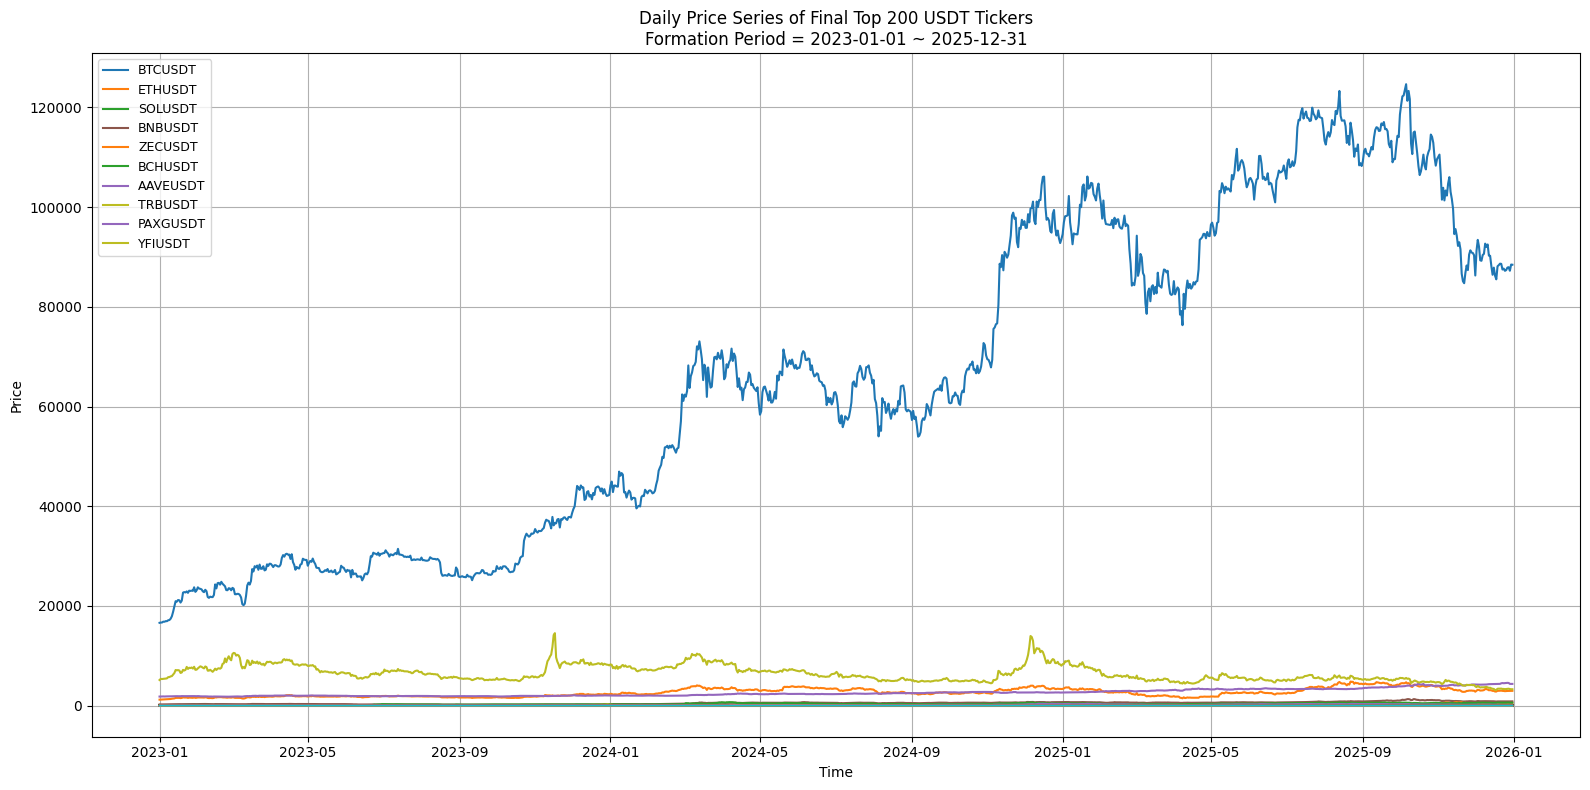

In [24]:
# Raw price graph 가격 상위 10개 표시

top10_price_tickers = (
    price_panel_daily.max(skipna=True)
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

print("Top 10 highest-price tickers:")
print(top10_price_tickers)

plt.figure(figsize=(16, 8))
ax = plt.gca()

for ticker in price_panel_daily.columns:
    if ticker in top10_price_tickers:
        ax.plot(
            price_panel_daily.index,
            price_panel_daily[ticker],
            linewidth=1.5,
            alpha=1.0,
            label=ticker
        )
    else:
        ax.plot(
            price_panel_daily.index,
            price_panel_daily[ticker],
            linewidth=1.0,
            alpha=1.0
        )

ax.set_title(
    f"Daily Price Series of Final Top {TOP_N} USDT Tickers\n"
    f"Formation Period = {FORMATION_START} ~ {FORMATION_END}"
)
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.grid(True)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

Excluded tickers: ['BTCUSDT', 'YFIUSDT']
Remaining tickers: 198


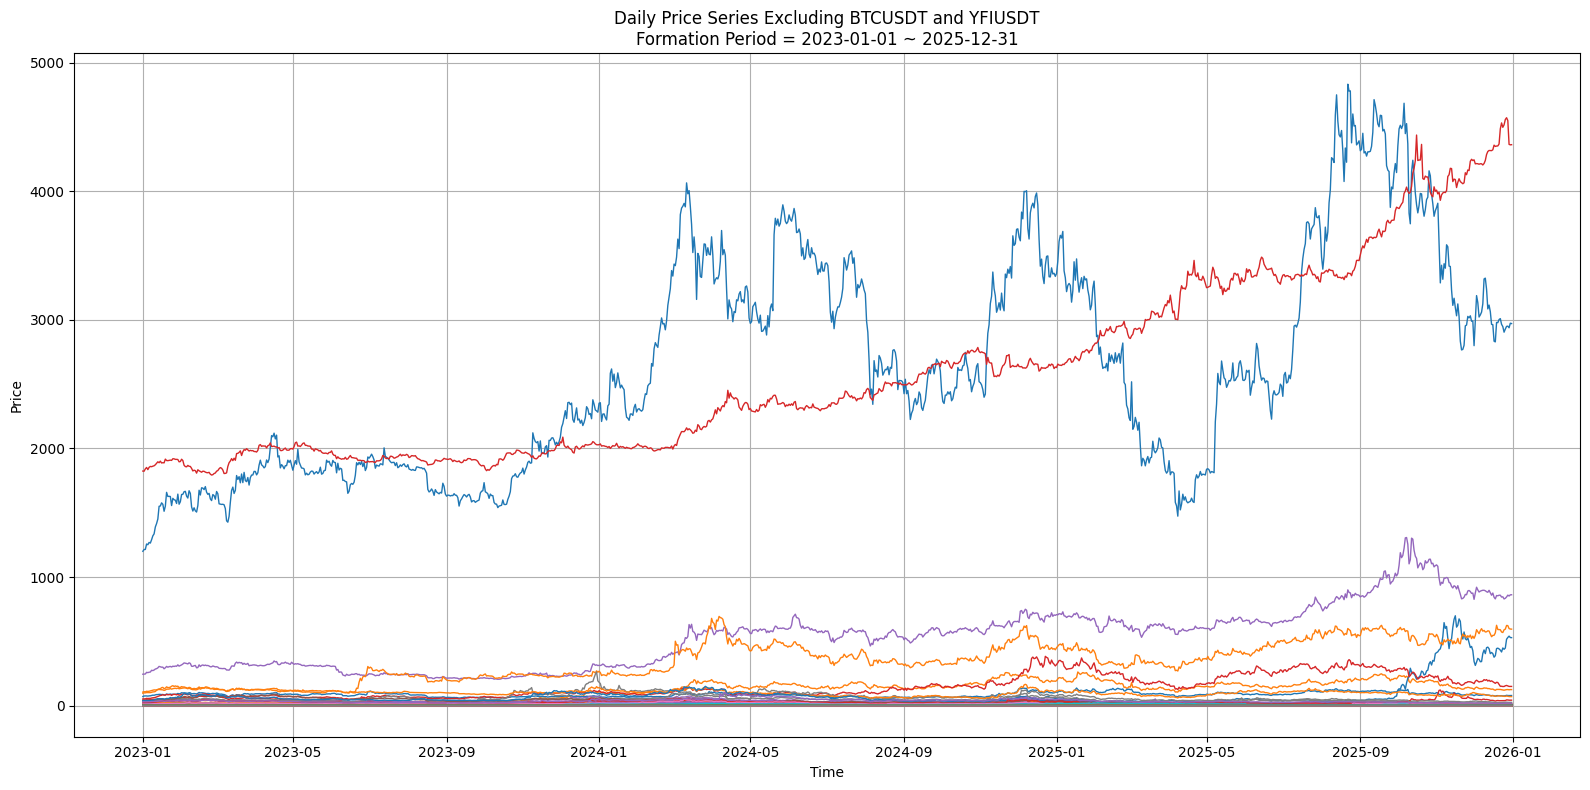

In [25]:
# ============================================================
# Raw price graph excluding BTCUSDT and YFIUSDT
# ============================================================

plt.close("all")

exclude_tickers = ["BTCUSDT", "YFIUSDT"]

price_panel_daily_ex_btc_yfi = price_panel_daily.drop(
    columns=[ticker for ticker in exclude_tickers if ticker in price_panel_daily.columns]
)

print("Excluded tickers:", exclude_tickers)
print("Remaining tickers:", price_panel_daily_ex_btc_yfi.shape[1])

plt.figure(figsize=(16, 8))
ax = plt.gca()

for ticker in price_panel_daily_ex_btc_yfi.columns:
    ax.plot(
        price_panel_daily_ex_btc_yfi.index,
        price_panel_daily_ex_btc_yfi[ticker],
        linewidth=1.0,
        alpha=1.0
    )

ax.set_title(
    f"Daily Price Series Excluding BTCUSDT and YFIUSDT\n"
    f"Formation Period = {FORMATION_START} ~ {FORMATION_END}"
)
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.grid(True)

plt.tight_layout()
plt.show()